# Rotten Tomatoes movies and tv shows rating analysis

The dataset is from [Kaggle: Rotten Tomatoes Critics and Audience Scores](https://www.kaggle.com/datasets/matepapava/rotten-tomatoes-critics-and-audience-scores) and contains 3549 movies and 44 tv shows, including year, critics score, audience score, cast and genres.

## Table of contents
- Asking questions
- Data wrangling
- EDA
- Conclusions

# Asking questions
- Q1: Which year produced movies/tv shows with highest average scores?
- Q2: Which genres are mostly produced for movies and tv shows?
- Q3: Which genres are associated with high ratings for movies and tv shows?
- Q4: Are critics scores and audience scores for movies and tv shows always aligned?
- Q5: Which actor in movies and tv shows is associated with high ratings?

# Data wranging
## Imports

In [1]:
import numpy as np
import pandas as pd

In [2]:
print(np.__version__)
print(pd.__version__)
print(pd.__file__)

1.26.4
2.3.3
/Users/bian0001/anaconda3/envs/pandas_ok/lib/python3.11/site-packages/pandas/__init__.py


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

## Read dataset

In [4]:
df = pd.read_json("/Users/bian0001/data/RottenTomatoes/new_rotten_tomatoes_dataset.json")
df.head()

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews
0,Prisoner of War,2025,58c6801a-d7d0-49d4-a200-07e9f8e6004f,prisoner_of_war,movie,67.0,NaN,"[Action, Mystery & Thriller, War]",[],"[{'role': 'Actor', 'emsId': 'c8ab0109-b9e3-318...",None,Prisoner of War,https://resizing.flixster.com/BBVn1zu0ytWcN2rI...,"[{'critic_name': 'Keith Garlington', 'review_t..."
1,War of the Worlds,2025,2828f421-1ed7-430d-94c3-e19235ba0d43,war_of_the_worlds_2025,movie,4.0,20.0,"[Sci-Fi, Adventure, Drama, Mystery & Thriller]",[],"[{'role': 'Actor', 'emsId': 'c745b7d3-1c29-394...",Critics Consensus\n \nStranding Ice Cub...,War of the Worlds,https://resizing.flixster.com/YwVygNhpYTtDgJ5N...,"[{'critic_name': 'Clement Tyler Obropta', 'rev..."
2,Female War: A Nasty Deal,2015,05b14108-fbb6-3e04-86f7-cdc2d40bef0b,female_war_a_nasty_deal,movie,NaN,83.0,[Drama],[],"[{'role': 'Actor', 'emsId': 'a693f4c5-2ca7-33a...",None,Female War: A Nasty Deal,none,[]
3,This Means War,2012,de81052c-61c1-36ba-9366-5c396e4a2b67,this_means_war,movie,24.0,56.0,"[Action, Comedy]",[],"[{'role': 'Actor', 'emsId': 'e9ed7eb8-7773-3b6...",Critics Consensus\n \nA career lowlight...,This Means War,https://resizing.flixster.com/gdTg56URfE7W9P3F...,"[{'critic_name': 'Brian Eggert', 'review_text'..."
4,Love+War,2025,e62b7347-0c01-44d9-a36a-5310b461243b,love_and_war_2025,movie,100.0,NaN,"[Documentary, War, Biography, History]",[],"[{'role': 'Self', 'emsId': '165fbc83-6be1-3167...",None,Love+War,https://resizing.flixster.com/RlYWkCPgGQfWIsZ-...,"[{'critic_name': 'Jeremy Aspinall', 'review_te..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3593 entries, 0 to 3592
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3593 non-null   object 
 1   year            3593 non-null   int64  
 2   emsId           3593 non-null   object 
 3   vanity          3593 non-null   object 
 4   type            3593 non-null   object 
 5   critics_score   2747 non-null   float64
 6   audience_score  3442 non-null   float64
 7   genres          3593 non-null   object 
 8   directors       3593 non-null   object 
 9   cast            3593 non-null   object 
 10  full_consensus  1892 non-null   object 
 11  full_title      3593 non-null   object 
 12  full_image      3593 non-null   object 
 13  critic_reviews  3593 non-null   object 
dtypes: float64(2), int64(1), object(11)
memory usage: 393.1+ KB


The dataframe has 3593 rows and 14 columns.

## First Glance Questions

### 1. What is the year range of the movies in this dataset?

In [6]:
max_year = max(df['year'])
print(max_year)

2025


In [7]:
min_year = min(df['year'])
print(min_year)

1914


In [8]:
len(df['emsId'].unique())

3593

The dataset contains 3593 unique emsId movies and tv shows between 1914 and 2025. 

### 2. What are the entertainment types in this dataset?

In [9]:
df['type'].unique()

array(['movie', 'tv'], dtype=object)

### 3. Is the director column completely empty?

In [10]:
df['directors'].str.split().unique()

array([nan], dtype=object)

Yes, the directors column can be removed. 

### 4. What is in the df['cast'] column?

In [11]:
df['cast'].iloc[1]

[{'role': 'Actor',
  'emsId': 'c745b7d3-1c29-394e-a2e4-472958578397',
  'name': 'Ice Cube',
  'personId': '827'},
 {'role': 'Actor',
  'emsId': 'd1906719-6697-3263-8e25-c02076cae063',
  'name': 'Eva Longoria',
  'personId': '276424'},
 {'role': 'Actor',
  'emsId': '0b061a67-2089-3e6a-997f-2eb9f1bdb8d7',
  'name': "Michael O'Neill",
  'personId': '217994'},
 {'role': 'Actor',
  'emsId': '7d76d4e9-0ceb-311d-b33f-32f85c4668d6',
  'name': 'Olivia DeLaurentis',
  'personId': '1175958'},
 {'role': 'Actor',
  'emsId': 'a66e75f9-127b-36dc-9045-0decb4cd145d',
  'name': 'Clark Gregg',
  'personId': '170976'},
 {'role': 'Actor',
  'emsId': '9e8525b3-a37f-33f6-a7c2-7cd8b485a46e',
  'name': 'Iman Benson',
  'personId': '879570'},
 {'role': 'Actor',
  'emsId': '8bfc862c-5313-31bc-983e-54082eb39274',
  'name': 'Henry Hunter Hall',
  'personId': '751183'},
 {'role': 'Actor',
  'emsId': '6b1124af-52b2-3cf3-8c3e-9641beb1ecf0',
  'name': 'Devon Bostick',
  'personId': '275671'},
 {'role': 'Actor',
  'ems

In [12]:
df['cast'].iloc[1][0]['name']

'Ice Cube'

**It contains a list of dictionaries, that listed the roles and the names of the people in the movie/show.** 

### 5. Columns need text analysis

In [13]:
text_col = ['full_consensus', 'critic_reviews', 'genres']

## Separating Movies and TV

In [14]:
df_movies = df[df['type'] == 'movie']
df_tv = df[df['type'] == 'tv']

In [15]:
print('Entries for movies:', len(df_movies))
print('Entries for tv shows', len(df_tv))

Entries for movies: 3549
Entries for tv shows 44


# EDA about movies

In [16]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3549 entries, 0 to 3592
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3549 non-null   object 
 1   year            3549 non-null   int64  
 2   emsId           3549 non-null   object 
 3   vanity          3549 non-null   object 
 4   type            3549 non-null   object 
 5   critics_score   2717 non-null   float64
 6   audience_score  3398 non-null   float64
 7   genres          3549 non-null   object 
 8   directors       3549 non-null   object 
 9   cast            3549 non-null   object 
 10  full_consensus  1870 non-null   object 
 11  full_title      3549 non-null   object 
 12  full_image      3549 non-null   object 
 13  critic_reviews  3549 non-null   object 
dtypes: float64(2), int64(1), object(11)
memory usage: 415.9+ KB


In [17]:
cols_m = df_movies.columns[df_movies.apply(lambda s: s.map(type).ne(list).all())]
df_movies.duplicated(subset=cols_m).sum()

0

## Year span of movies in this dataset

In [18]:
print('Earliest movie in this dataset:', min(df_movies['year']))

Earliest movie in this dataset: 1914


In [19]:
print('Earliest movie in this dataset:', df_movies[df_movies['year'] == 1914]['title'].iloc[0])

Earliest movie in this dataset: In the Land of the War Canoes


In [20]:
print('Latest movie in this dataset:', max(df_movies['year']))

Latest movie in this dataset: 2025


In [21]:
print(df_movies[df_movies['year'] == 2025].shape)

(210, 14)


There are 210 movies in 2025.

In [22]:
df_movies_by_year = df_movies.groupby(['year'])['title'].count()
df_movies_by_year.head()

year
1914    1
1919    2
1924    1
1925    1
1929    2
Name: title, dtype: int64

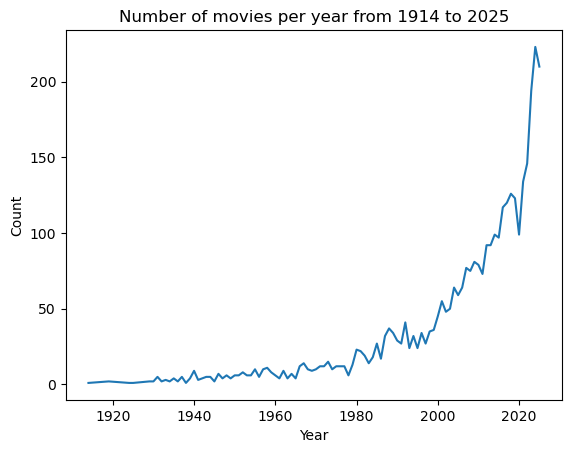

In [23]:
sns.lineplot(x = df_movies_by_year.index, y = df_movies_by_year)
plt.title('Number of movies per year from 1914 to 2025')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

## Q1: Which year produced movies with highest average scores?

In [24]:
movies_critics_score_by_year = df_movies.groupby(['year'])['critics_score'].agg(
    n_critics_score_by_year = 'count',
    mean_critics_score_by_year = 'mean',
    std_critics_score_by_year = 'std'
)
movies_critics_score_by_year.sort_values('mean_critics_score_by_year', ascending = False).head()

,n_critics_score_by_year,mean_critics_score_by_year,std_critics_score_by_year
year,,,
1929,2,100.0,0.0
1924,1,100.0,NaN
1943,2,100.0,0.0
1936,1,100.0,NaN
1925,1,98.0,NaN


In [25]:
movies_audience_score_by_year = df_movies.groupby(['year'])['audience_score'].agg(
    n_audience_score_by_year = 'count',
    mean_audience_score_by_year = 'mean',
    std_audience_score_by_year = 'std'
)
movies_audience_score_by_year.sort_values('mean_audience_score_by_year', ascending = False).head()

,n_audience_score_by_year,mean_audience_score_by_year,std_audience_score_by_year
year,,,
1925,1,93.000000,NaN
1938,1,89.000000,NaN
1945,2,89.000000,4.242641
1930,2,86.000000,4.242641
1964,7,84.285714,11.101265


## Movie genres

In [26]:
df_movies_genre_exploded = df_movies.explode('genres')
df_movies_genre_exploded.head()

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews
0,Prisoner of War,2025,58c6801a-d7d0-49d4-a200-07e9f8e6004f,prisoner_of_war,movie,67.0,NaN,Action,[],"[{'role': 'Actor', 'emsId': 'c8ab0109-b9e3-318...",None,Prisoner of War,https://resizing.flixster.com/BBVn1zu0ytWcN2rI...,"[{'critic_name': 'Keith Garlington', 'review_t..."
0,Prisoner of War,2025,58c6801a-d7d0-49d4-a200-07e9f8e6004f,prisoner_of_war,movie,67.0,NaN,Mystery & Thriller,[],"[{'role': 'Actor', 'emsId': 'c8ab0109-b9e3-318...",None,Prisoner of War,https://resizing.flixster.com/BBVn1zu0ytWcN2rI...,"[{'critic_name': 'Keith Garlington', 'review_t..."
0,Prisoner of War,2025,58c6801a-d7d0-49d4-a200-07e9f8e6004f,prisoner_of_war,movie,67.0,NaN,War,[],"[{'role': 'Actor', 'emsId': 'c8ab0109-b9e3-318...",None,Prisoner of War,https://resizing.flixster.com/BBVn1zu0ytWcN2rI...,"[{'critic_name': 'Keith Garlington', 'review_t..."
1,War of the Worlds,2025,2828f421-1ed7-430d-94c3-e19235ba0d43,war_of_the_worlds_2025,movie,4.0,20.0,Sci-Fi,[],"[{'role': 'Actor', 'emsId': 'c745b7d3-1c29-394...",Critics Consensus\n \nStranding Ice Cub...,War of the Worlds,https://resizing.flixster.com/YwVygNhpYTtDgJ5N...,"[{'critic_name': 'Clement Tyler Obropta', 'rev..."
1,War of the Worlds,2025,2828f421-1ed7-430d-94c3-e19235ba0d43,war_of_the_worlds_2025,movie,4.0,20.0,Adventure,[],"[{'role': 'Actor', 'emsId': 'c745b7d3-1c29-394...",Critics Consensus\n \nStranding Ice Cub...,War of the Worlds,https://resizing.flixster.com/YwVygNhpYTtDgJ5N...,"[{'critic_name': 'Clement Tyler Obropta', 'rev..."


In [27]:
df_movie_genre_count = df_movies_genre_exploded['genres'].value_counts().reset_index()
df_movie_genre_count

,genres,count
0,Drama,1411
1,Mystery & Thriller,915
2,Comedy,835
3,Horror,635
4,Action,615
5,Adventure,466
6,Fantasy,345
7,Sci-Fi,301
8,Crime,276
9,Romance,266


The top 5 genres of movies are Drama, Mystery & Thriller, Comedy, Horror and Action.

In [28]:
len(df_movies_genre_exploded['genres'].unique())

30

There are 30 different genres in movies.

## Q2: Which genres are mostly produced for movies?

<Figure size 1000x1000 with 0 Axes>

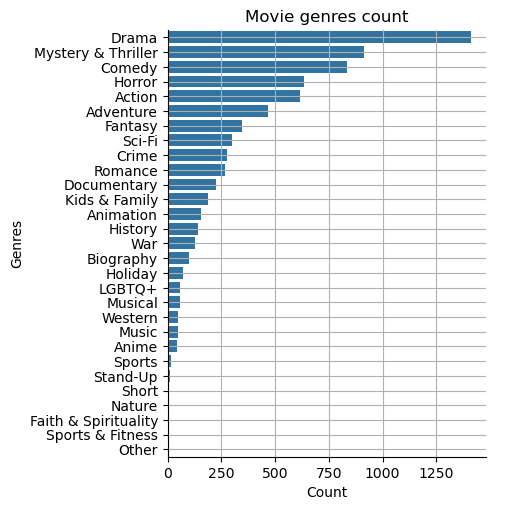

In [29]:
fig = plt.figure(figsize = (10,10))
g_movie = sns.catplot(data = df_movie_genre_count, x = 'count', y = 'genres', kind = 'bar')
g_movie.set_xlabels('Count')
g_movie.set_ylabels('Genres')
plt.title('Movie genres count')
plt.grid()
plt.show()

In [30]:
df_movies_2025 = df_movies_genre_exploded[df_movies_genre_exploded['year'] == 2025]
df_movies_2025_by_genre = df_movies_2025.groupby(['genres'])['title'].count().sort_values(ascending = False).reset_index()
df_movies_2025_by_genre

,genres,title
0,Drama,97
1,Mystery & Thriller,82
2,Action,55
3,Comedy,52
4,Horror,38
5,Adventure,36
6,Crime,25
7,Fantasy,21
8,Sci-Fi,17
9,Romance,17


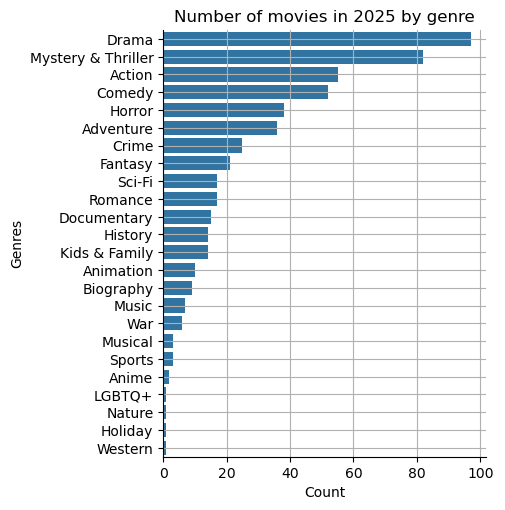

In [31]:
sns.catplot(data = df_movies_2025_by_genre, x = 'title', y = 'genres', kind = 'bar')
plt.title('Number of movies in 2025 by genre')
plt.xlabel('Count')
plt.ylabel('Genres')
plt.grid()
plt.show()

The top 3 movie genres in 2025 are Drama, Mystery & Thriller, and Action.

### Highest and lowest rated drama movies

In [32]:
highest_critics_score_drama = max(df_movies_genre_exploded[df_movies_genre_exploded['genres'] == 'Drama']['critics_score'])
highest_critics_score_drama

100.0

In [33]:
lowest_critics_score_drama = min(df_movies_genre_exploded[df_movies_genre_exploded['genres'] == 'Drama']['critics_score'])
lowest_critics_score_drama

0.0

In [34]:
df_movies_drama = df_movies_genre_exploded[df_movies_genre_exploded['genres'] == 'Drama']
df_movies_drama.shape

(1411, 14)

In [35]:
df_movies_drama[df_movies_drama['critics_score'] == highest_critics_score_drama]['title']

15                World War III
25                War and Peace
33              Warsaw Uprising
77                  Path to War
151     This Is Not a War Story
                 ...           
3329         Totally F... ed Up
3333       Deliver Us From Evil
3426            The Dark Corner
3438      Taxi to the Dark Side
3536           A Dark, Dark Man
Name: title, Length: 77, dtype: object

In [36]:
df_movies_drama[df_movies_drama['critics_score'] == lowest_critics_score_drama]['title']

303               365 Days: This Day
412                          Any Day
1059                        365 Days
1317               The Next 365 Days
2002                       City Rats
3253                       Unfreedom
3316    Once Upon a Time in Brooklyn
3342                Generation Um...
3349                     Dark Crimes
3435                       Dark Tide
Name: title, dtype: object

In [37]:
df_movies_drama[df_movies_drama['audience_score'] == max(df_movies_drama['audience_score'])][['title', 'year']]

,title,year
215,Japanese War Bride,1952
216,Twenty Days Without War,1976
232,War and Peace Part III: The Year 1812,1967
241,"Searching for Home, Coming Back From War",2015
445,"That Day, on the Beach",1983
519,A Perfect Day for Caribou,2022
1763,The Roundup,2022
1783,The City,1998
1973,The City,2023
2218,After All,2025


In [38]:
df_movies_drama[df_movies_drama['audience_score'] == min(df_movies_drama['audience_score'])][['title', 'year']]

,title,year
111,Mob War,1989
1759,Big City Blues,1999
2698,Hard Night Falling,2019
3574,Bettie Page: Dark Angel,2004


### Highest rated Mystery & Thriller movies

In [39]:
df_movies_myth_thriller = df_movies_genre_exploded[df_movies_genre_exploded['genres'] == 'Mystery & Thriller']
df_movies_myth_thriller.shape

(915, 14)

In [40]:
df_movies_myth_thriller[df_movies_myth_thriller['critics_score'] == np.max(df_movies_myth_thriller['critics_score'])][['title', 'year']]

,title,year
15,World War III,2022
374,A Day,2017
603,The Secret Agent,2025
821,The Terminator,1984
963,The Correspondent,2024
964,The Plague,2025
1241,100 Days to Live,2019
1243,Shadow of a Doubt,1943
1363,Double Blind,2023
1698,Red Riding: 1974,2009


In [41]:
df_movies_myth_thriller[df_movies_myth_thriller['audience_score'] == np.max(df_movies_myth_thriller['audience_score'])][['title','year']]

,title,year
1923,Broken City,2023
2970,Queen Rising,2024


### Highest rated Comedy movies

In [42]:
df_movies_comedy = df_movies_genre_exploded[df_movies_genre_exploded['genres'] == 'Comedy']
df_movies_comedy.shape

(835, 14)

In [43]:
df_movies_comedy[df_movies_comedy['critics_score'] == np.max(df_movies_comedy['critics_score'])][['title', 'year']]

,title,year
300,It's Such a Beautiful Day,2012
302,A Day in the Country,1936
355,On a Clear Day You Can See Forever,1970
420,At the End of the Day,2018
433,Lady for a Day,1933
606,Nirvanna the Band the Show the Movie,2025
916,One Cut of the Dead,2017
1522,Rambling Rose,1991
1535,Singin' in the Rain,1952
1708,The Rat Catcher,2023


In [44]:
df_movies_comedy[df_movies_comedy['audience_score'] == np.max(df_movies_comedy['audience_score'])][['title', 'year']]

,title,year
110,Kaguya-sama: Love Is War - The First Kiss that...,2022
1836,Cat City,1986
2761,O Homem que Desafiou o Diabo,2007
3348,Regarding Us,2024


## Q3: Which genres are associated with high ratings?

## Critics scores

In [45]:
avg_critics_score = np.mean(df_movies['critics_score'])
avg_critics_score = round(avg_critics_score, 2)
print('Average critics score for movies:', avg_critics_score)

Average critics score for movies: 67.77


In [46]:
df_movies_genre_exploded.groupby(['genres'])['critics_score'].agg(
    n_critics_scores_by_genre = 'count',
    critics_mean_by_genre = 'mean',
    critics_std_by_genre = 'std'    
).sort_values('critics_mean_by_genre', ascending = False)

,n_critics_scores_by_genre,critics_mean_by_genre,critics_std_by_genre
genres,,,
Nature,2,100.000000,0.000000
Stand-Up,3,100.000000,0.000000
Short,2,97.500000,3.535534
Documentary,175,92.462857,11.864055
Music,40,84.900000,14.233943
Anime,25,83.920000,20.141003
Biography,87,80.747126,17.964577
LGBTQ+,52,80.307692,20.418694
Sports & Fitness,1,80.000000,NaN


In [47]:
df_movies_critics_score_by_year = df_movies.groupby(['year'])['critics_score'].agg(
    n_critics_score = 'count',
    mean_critics_score = 'mean',
    std_critics_score = 'std'
)
df_movies_critics_score_by_year = df_movies_critics_score_by_year.reset_index()
df_movies_critics_score_by_year

,year,n_critics_score,mean_critics_score,std_critics_score
0,1914,0,NaN,NaN
1,1919,1,96.000000,NaN
2,1924,1,100.000000,NaN
3,1925,1,98.000000,NaN
4,1929,2,100.000000,0.000000
...,...,...,...,...
96,2021,108,70.731481,25.481020
97,2022,125,72.960000,25.517989
98,2023,159,73.792453,23.082701
99,2024,195,72.164103,24.233906


In [48]:
movie_year_range = np.arange(1920, 2030, 10)
movie_year_range

array([1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020])

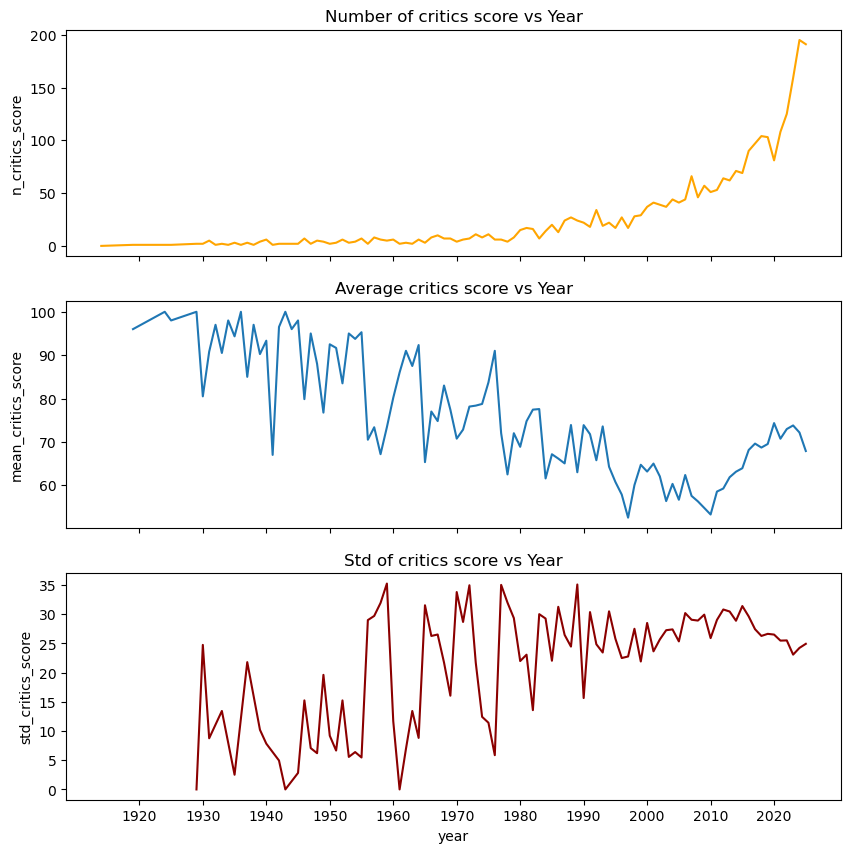

In [49]:
fig, axes = plt.subplots(3, sharex = True, figsize = (10,10))
sns.lineplot(data = df_movies_critics_score_by_year, x = 'year', y = 'mean_critics_score', ax = axes[1])
sns.lineplot(data = df_movies_critics_score_by_year, x = 'year', y = 'n_critics_score', ax = axes[0], color = 'orange')
sns.lineplot(data = df_movies_critics_score_by_year, x = 'year', y = 'std_critics_score', ax = axes[2], color = 'darkred')
axes[0].set_title('Number of critics score vs Year')
axes[1].set_title('Average critics score vs Year')
axes[2].set_title('Std of critics score vs Year')
plt.xticks(movie_year_range)
plt.show()

As the number of movies explodes in recent years, so are the number of critics reviews. The average review scores by year show a declining trend overall, with a slight uplift since ~2010. The std of critics scores are consistent in rencent years probably due to the increase of review numbers.

## Audience scores

In [50]:
avg_audience_score_movies = np.mean(df_movies['audience_score'])
print('Average audience score for movies is:', round(avg_audience_score_movies,2))

Average audience score for movies is: 63.61


In [51]:
df_movies_audience_score_by_genre = df_movies_genre_exploded.groupby(['genres'])['audience_score'].agg(
    audience_score_counts = 'count',
    audience_score_mean_by_genre = 'mean',
    audience_score_std_by_genre = 'std'
).sort_values('audience_score_mean_by_genre', ascending = False)
df_movies_audience_score_by_genre

,audience_score_counts,audience_score_mean_by_genre,audience_score_std_by_genre
genres,,,
Faith & Spirituality,2,91.000000,7.071068
Sports,11,86.363636,12.282286
Other,1,84.000000,NaN
Music,43,83.023256,12.012867
Documentary,177,81.474576,14.271741
Anime,42,81.452381,16.466081
Biography,89,80.595506,16.838618
History,128,76.023438,19.393750
Musical,51,73.196078,17.622735


There is a discrepency between critics appreciated and audience welcomed genres.

In [52]:
df_movies_audience_score_by_year = df_movies.groupby(['year'])['audience_score'].agg(
    n_audience_score_by_year = 'count',
    mean_audience_score_by_year = 'mean',
    std_audience_score_by_year = 'std'
).reset_index()
df_movies_audience_score_by_year

,year,n_audience_score_by_year,mean_audience_score_by_year,std_audience_score_by_year
0,1914,1,23.000000,NaN
1,1919,2,73.000000,22.627417
2,1924,1,58.000000,NaN
3,1925,1,93.000000,NaN
4,1929,2,81.500000,4.949747
...,...,...,...,...
96,2021,123,66.121951,24.153398
97,2022,139,70.525180,23.222094
98,2023,180,71.344444,22.229710
99,2024,180,71.233333,22.366950


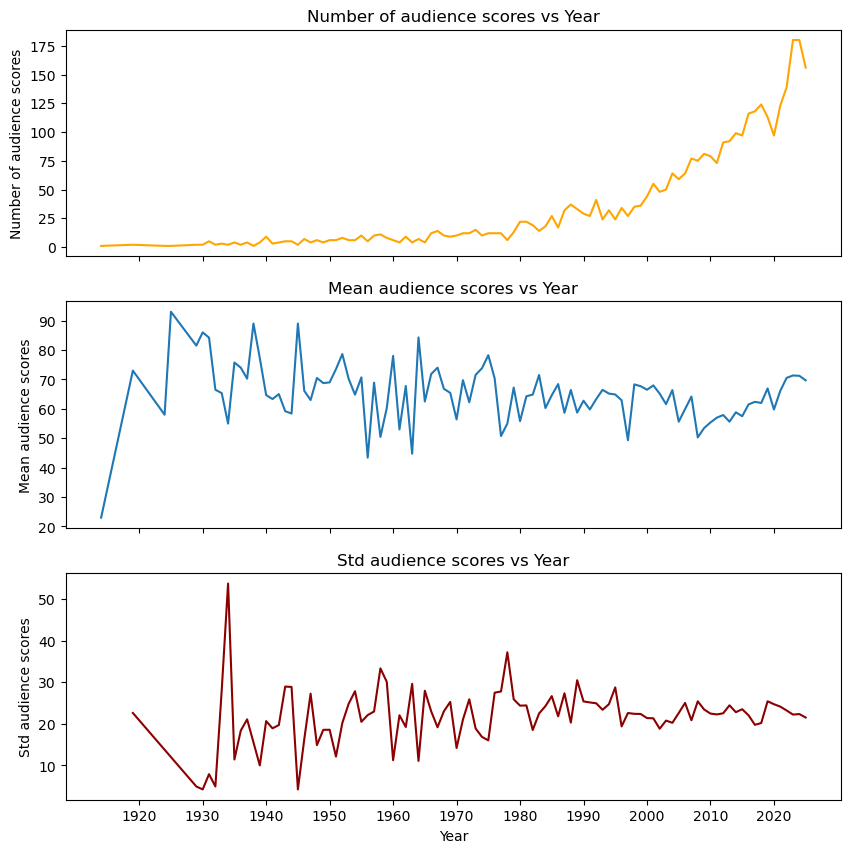

In [53]:
fig,axes = plt.subplots(3, sharex = True, figsize = (10,10))
sns.lineplot(data = df_movies_audience_score_by_year, x = 'year', y = 'n_audience_score_by_year', ax = axes[0], color = 'orange')
sns.lineplot(data = df_movies_audience_score_by_year, x = 'year', y = 'mean_audience_score_by_year', ax = axes[1])
sns.lineplot(data = df_movies_audience_score_by_year, x = 'year', y = 'std_audience_score_by_year', ax = axes[2], color = 'darkred')
axes[0].set_ylabel('Number of audience scores')
axes[0].set_title('Number of audience scores vs Year')
axes[1].set_ylabel('Mean audience scores')
axes[1].set_title('Mean audience scores vs Year')
axes[2].set_ylabel('Std audience scores')
axes[2].set_title('Std audience scores vs Year')
plt.xlabel('Year')
plt.xticks(movie_year_range)
plt.show()

The number of audience scores also increased drastically in recent year. The average of audience scores remains rather consistent, as well as the std.

## Q4: Are critics scores and audience scores always aligned?

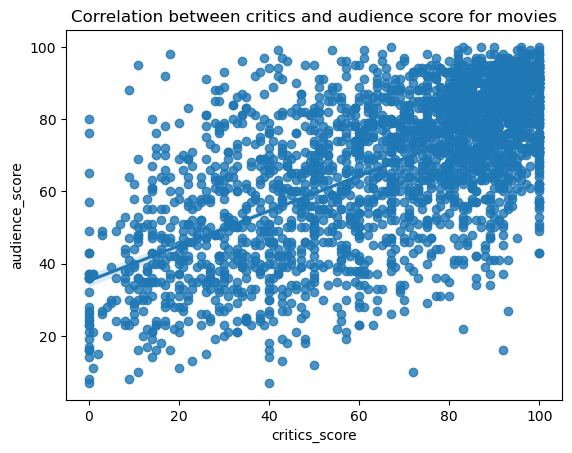

In [54]:
sns.regplot(data = df_movies, x = 'critics_score', y = 'audience_score')
plt.title('Correlation between critics and audience score for movies')
plt.show()

In [55]:
df_movies['critics_score'].corr(df_movies['audience_score'], method = 'spearman')

0.6127444532062061

In [56]:
df_movies['critics_score'].corr(df_movies['audience_score'], method = 'pearson')

0.637932757569111

#### Critics’ and audience scores show a weak positive correlation (Pearson r = 0.64).

## Casts

In [57]:
df_movies_cast_exploded = df_movies.explode('cast')
df_movies_cast_exploded.shape

(37578, 14)

In [58]:
df_movies_cast_exploded['cast'].iloc[0]

{'role': 'Actor',
 'emsId': 'c8ab0109-b9e3-3182-8651-dceadcdc54ee',
 'name': 'Scott Adkins',
 'personId': '290115'}

In [59]:
df_movies_cast_exploded['cast'].isnull().sum()

81

In [60]:
df_movies_cast_exploded_dropna = df_movies_cast_exploded.dropna(subset = 'cast')
df_movies_cast_exploded_dropna['cast'].isnull().sum()

0

In [61]:
df_movies_actors = (df_movies_cast_exploded_dropna['cast']
    .apply(lambda x: x.get('name') if x.get('role') == 'Actor' else None)
    .replace('', np.nan)
    .dropna()
    .unique()
    .tolist())
df_movies_actors[:10]

['Scott Adkins',
 'Peter Shinkoda',
 'Michael Copon',
 'Donald Cerrone',
 'Michael Rene Walton',
 'Gabbi Garcia',
 'Masanori Mimoto',
 'Gary Cairns',
 'Ice Cube',
 'Eva Longoria']

In [62]:
print('Number of actors for movies in this dataset:', len(df_movies_actors))

Number of actors for movies in this dataset: 22654


In [63]:
df_movies_actors_count = (df_movies_cast_exploded_dropna['cast']
    .apply(lambda x: x.get('name') if x.get('role') == 'Actor' else None)
    .replace('', np.nan)
    .dropna()
    .value_counts()).reset_index()
df_movies_actors_count.head(10)

,cast,count
0,Robert De Niro,23
1,Samuel L. Jackson,19
2,Willem Dafoe,19
3,Johnny Depp,19
4,Morgan Freeman,19
5,Ralph Fiennes,18
6,Christopher Walken,18
7,Brad Pitt,18
8,Alan Rickman,17
9,Tilda Swinton,17


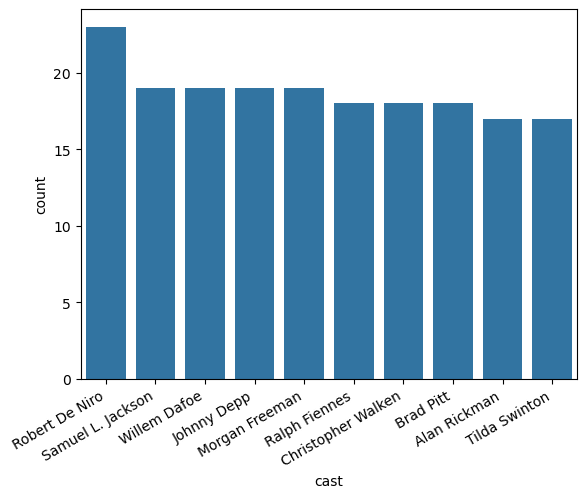

In [64]:
fig_actors = sns.barplot(data = df_movies_actors_count.head(10), x = 'cast', y = 'count')
plt.xticks(rotation = 30, ha = 'right')
plt.show()

In [65]:
top_10_appeared_actors = df_movies_actors_count[:10]['cast']

In [66]:
print('Top 10 appeared actors for movies in this dataset are ')
for actor in top_10_appeared_actors:
    print(f'- {actor}')

Top 10 appeared actors for movies in this dataset are 
- Robert De Niro
- Samuel L. Jackson
- Willem Dafoe
- Johnny Depp
- Morgan Freeman
- Ralph Fiennes
- Christopher Walken
- Brad Pitt
- Alan Rickman
- Tilda Swinton


### Actors in genres

#### Drama

In [67]:
df_movies_drama_cast_exploded = df_movies_drama.explode(['cast'])
df_movies_drama_cast_exploded.shape

(15556, 14)

In [68]:
df_movies_drama_cast_exploded.dropna(subset = 'cast', inplace = True)
df_movies_drama_cast_exploded.shape

(15551, 14)

In [69]:
df_movies_drama_actors = (df_movies_drama_cast_exploded['cast']
                            .apply(lambda x: x.get('name') if x.get('role') == 'Actor' else None)
                            .replace('', np.nan).dropna()
                            .unique().tolist()
                            )
print('Number of actors in drama movies:', len(df_movies_drama_actors))

Number of actors in drama movies: 11586


In [70]:
df_movies_drama_actors = (df_movies_drama_cast_exploded['cast']
                            .apply(lambda x: x.get('name') if x.get('role') == 'Actor' else None)
                            .replace('', np.nan).dropna()
                            .value_counts()
                            )
df_movies_drama_actors.head(10)

cast
Robert De Niro       17
Al Pacino            14
Brad Pitt            13
Willem Dafoe         13
Tilda Swinton        12
Robert Duvall        11
Bryan Cranston       11
Leonardo DiCaprio    11
Tom Hanks            11
Denzel Washington    10
Name: count, dtype: int64

#### Mystery & Thriller

In [71]:
df_movies_myth_thriller_cast_exploded = df_movies_myth_thriller.explode('cast')
df_movies_myth_thriller_cast_exploded.shape

(9773, 14)

In [72]:
df_movies_myth_thriller_cast_exploded.dropna(subset = 'cast', inplace = True)
df_movies_myth_thriller_cast_exploded.shape

(9772, 14)

In [73]:
df_movies_myth_thriller_cast_exploded['cast'].iloc[0]

{'role': 'Actor',
 'emsId': 'c8ab0109-b9e3-3182-8651-dceadcdc54ee',
 'name': 'Scott Adkins',
 'personId': '290115'}

In [74]:
df_movies_myth_thriller_actors = (df_movies_myth_thriller_cast_exploded['cast']
                                 .apply(lambda x: x.get('name') if x.get('role') == 'Actor' else None)
                                 .replace('', np.nan).dropna()
                                 .unique().tolist()
                                 )
print('Number of actors in comedy movies:', len(df_movies_myth_thriller_actors))

Number of actors in comedy movies: 7767


In [75]:
df_movies_myth_thriller_actors = (df_movies_myth_thriller_cast_exploded['cast']
                                 .apply(lambda x: x.get('name') if x.get('role') == 'Actor' else None)
                                 .replace('', np.nan).dropna()
                                 .value_counts()
                                 )
df_movies_myth_thriller_actors.head(10)

cast
Ralph Fiennes        10
Willem Dafoe          9
Bruce Willis          9
Mark Wahlberg         9
Ben Affleck           8
Alan Rickman          8
Ethan Hawke           8
Brendan Gleeson       8
Denzel Washington     7
Guy Pearce            7
Name: count, dtype: int64

In [76]:
print('The number of actors in both drama and mystery & thriller movies:', 
      len(set(df_movies_drama_actors).intersection(set(df_movies_myth_thriller_actors))))

The number of actors in both drama and mystery & thriller movies: 10


#### Comedy

In [77]:
df_movies_comedy_cast_exploded = df_movies_comedy.explode('cast')
df_movies_comedy_cast_exploded.dropna(subset = 'cast', inplace = True)
df_movies_comedy_cast_exploded.shape

(9891, 14)

In [78]:
df_movies_comedy_actors = (df_movies_comedy_cast_exploded['cast']
                          .apply(lambda x: x.get('name') if x.get('role') == 'Actor' else None)
                          .replace('', np.nan).dropna()
                          .unique().tolist()
                          )

In [79]:
print('Number of actors in comedy:', len(df_movies_comedy_actors))

Number of actors in comedy: 6708


In [80]:
df_movies_comedy_actors = (df_movies_comedy_cast_exploded['cast']
                          .apply(lambda x: x.get('name') if x.get('role') == 'Actor' else None)
                          .replace('', np.nan).dropna()
                          .value_counts()
                          )
df_movies_comedy_actors.head(10)

cast
Bill Murray           14
John Goodman          11
Paul Rudd             11
Zach Galifianakis     10
Hugh Grant             9
Michelle Pfeiffer      9
Christopher Walken     8
Jim Carrey             8
Christopher Lloyd      8
Adam Sandler           7
Name: count, dtype: int64

In [81]:
print('Number of actors in both drama and comedy:', 
      len(set(df_movies_drama_actors).intersection(df_movies_comedy_actors)))

Number of actors in both drama and comedy: 12


In [82]:
print('Number of actors in both mystery & thriller and comedy movies:', 
      len(set(df_movies_myth_thriller_actors).intersection(df_movies_comedy_actors)))

Number of actors in both mystery & thriller and comedy movies: 10


### New actors in recent 5 years

In [83]:
df_movies_5years = df_movies[df_movies['year'] >= 2021]
df_movies_5years.shape

(907, 14)

In [84]:
df_movies_5years_cast_exploded = df_movies_5years.explode('cast')
df_movies_5years_cast_exploded.shape

(8392, 14)

In [85]:
df_movies_5years_cast_exploded.dropna(subset = 'cast', inplace = True)
df_movies_5years_cast_exploded.shape

(8360, 14)

In [86]:
df_movies_5years_actors = (df_movies_5years_cast_exploded['cast']
                            .apply(lambda x: x.get('name') if x.get('role') == 'Actor' else None)
                            .replace('', np.nan)
                            .dropna()
                            .value_counts()
                          )
df_movies_5years_actors = df_movies_5years_actors.reset_index()
df_movies_5years_actors.head(10)

,cast,count
0,David Dastmalchian,10
1,Dave Bautista,10
2,Cary Elwes,8
3,Ralph Fiennes,7
4,Bill Murray,7
5,Willem Dafoe,7
6,Chiwetel Ejiofor,7
7,Djimon Hounsou,6
8,Timothée Chalamet,6
9,Guy Pearce,6


In [87]:
print('Top 10 most appeared actors in recent 5 years:')
for actor in df_movies_5years_actors.head(10)['cast']:
    print(f'- {actor}')

Top 10 most appeared actors in recent 5 years:
- David Dastmalchian
- Dave Bautista
- Cary Elwes
- Ralph Fiennes
- Bill Murray
- Willem Dafoe
- Chiwetel Ejiofor
- Djimon Hounsou
- Timothée Chalamet
- Guy Pearce


## Q5: Which actor is associated with high ratings?

In [88]:
df_movies_cast_exploded_dropna['cast'].iloc[0]

{'role': 'Actor',
 'emsId': 'c8ab0109-b9e3-3182-8651-dceadcdc54ee',
 'name': 'Scott Adkins',
 'personId': '290115'}

In [89]:
movie_actors_reviews = df_movies_cast_exploded_dropna.assign(
    actor_name = df_movies_cast_exploded_dropna['cast'].apply(lambda x: x.get('name') if x.get('role') == 'Actor' else None)
)

In [90]:
movie_actors_reviews.head()

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews,actor_name
0,Prisoner of War,2025,58c6801a-d7d0-49d4-a200-07e9f8e6004f,prisoner_of_war,movie,67.0,NaN,"[Action, Mystery & Thriller, War]",[],"{'role': 'Actor', 'emsId': 'c8ab0109-b9e3-3182...",None,Prisoner of War,https://resizing.flixster.com/BBVn1zu0ytWcN2rI...,"[{'critic_name': 'Keith Garlington', 'review_t...",Scott Adkins
0,Prisoner of War,2025,58c6801a-d7d0-49d4-a200-07e9f8e6004f,prisoner_of_war,movie,67.0,NaN,"[Action, Mystery & Thriller, War]",[],"{'role': 'Actor', 'emsId': '2fd91448-fe84-3b22...",None,Prisoner of War,https://resizing.flixster.com/BBVn1zu0ytWcN2rI...,"[{'critic_name': 'Keith Garlington', 'review_t...",Peter Shinkoda
0,Prisoner of War,2025,58c6801a-d7d0-49d4-a200-07e9f8e6004f,prisoner_of_war,movie,67.0,NaN,"[Action, Mystery & Thriller, War]",[],"{'role': 'Actor', 'emsId': '7d4a5890-de66-3bee...",None,Prisoner of War,https://resizing.flixster.com/BBVn1zu0ytWcN2rI...,"[{'critic_name': 'Keith Garlington', 'review_t...",Michael Copon
0,Prisoner of War,2025,58c6801a-d7d0-49d4-a200-07e9f8e6004f,prisoner_of_war,movie,67.0,NaN,"[Action, Mystery & Thriller, War]",[],"{'role': 'Actor', 'emsId': 'ed07d048-dca0-398f...",None,Prisoner of War,https://resizing.flixster.com/BBVn1zu0ytWcN2rI...,"[{'critic_name': 'Keith Garlington', 'review_t...",Donald Cerrone
0,Prisoner of War,2025,58c6801a-d7d0-49d4-a200-07e9f8e6004f,prisoner_of_war,movie,67.0,NaN,"[Action, Mystery & Thriller, War]",[],"{'role': 'Actor', 'emsId': '8417538d-e362-3851...",None,Prisoner of War,https://resizing.flixster.com/BBVn1zu0ytWcN2rI...,"[{'critic_name': 'Keith Garlington', 'review_t...",Michael Rene Walton


In [91]:
movie_actors_critics_reviews = movie_actors_reviews.groupby('actor_name')['critics_score'].agg(
    n_critics_score_by_actor = 'count',
    mean_critics_score_by_actor = 'mean',
    std_critics_score_by_actor = 'std'
).sort_values('mean_critics_score_by_actor', ascending = False)

In [92]:
top_10_critics_review_actors = (movie_actors_critics_reviews[movie_actors_critics_reviews['n_critics_score_by_actor'] > 10]
    .reset_index().head(10))

In [93]:
top_10_critics_review_actors

,actor_name,n_critics_score_by_actor,mean_critics_score_by_actor,std_critics_score_by_actor
0,Jeremy Renner,12,89.666667,7.049608
1,Maggie Smith,13,82.769231,13.760777
2,Mads Mikkelsen,11,81.909091,18.928574
3,Robert Redford,11,81.090909,20.042228
4,Matt Damon,11,80.727273,15.492520
5,Benedict Cumberbatch,15,79.666667,16.964950
6,Tilda Swinton,17,79.529412,13.346899
7,Alan Rickman,14,79.357143,14.361311
8,Judy Greer,11,79.181818,17.468933
9,Ralph Fiennes,18,78.111111,20.809751


In [94]:
print('The top 10 actors with more than 10 critics scores and highest average critics scores are:')
for name in top_10_critics_review_actors['actor_name']:
    print(name)

The top 10 actors with more than 10 critics scores and highest average critics scores are:
Jeremy Renner
Maggie Smith
Mads Mikkelsen
Robert Redford
Matt Damon
Benedict Cumberbatch
Tilda Swinton
Alan Rickman
Judy Greer
Ralph Fiennes


In [95]:
movie_actors_audience_reviews = movie_actors_reviews.groupby('actor_name')['audience_score'].agg(
    n_audience_score_by_actor = 'count',
    mean_audience_score_by_actor = 'mean',
    std_audience_score_by_actor = 'std'
).sort_values('mean_audience_score_by_actor', ascending = False).reset_index()
movie_actors_audience_reviews.head()

,actor_name,n_audience_score_by_actor,mean_audience_score_by_actor,std_audience_score_by_actor
0,Jace Nicole,1,100.0,NaN
1,Jeb Berrier,1,100.0,NaN
2,Janette Lane Bradbury,1,100.0,NaN
3,Amit Ulman,1,100.0,NaN
4,James Kelly,1,100.0,NaN


In [96]:
top10_movie_actors_audience_reviews = (movie_actors_audience_reviews[movie_actors_audience_reviews['n_audience_score_by_actor'] > 10]
                                      .head(10)
                                      )
top10_movie_actors_audience_reviews

,actor_name,n_audience_score_by_actor,mean_audience_score_by_actor,std_audience_score_by_actor
3919,Jeremy Renner,11,84.545455,5.820028
4708,Benedict Cumberbatch,15,82.066667,6.922702
5433,Chris Evans,12,80.416667,17.201788
5450,Chris Hemsworth,12,80.166667,13.085963
5451,Jon Bernthal,12,80.083333,17.296654
5735,Chiwetel Ejiofor,13,79.846154,16.955069
5751,Orlando Bloom,13,79.615385,15.063966
5781,Paul Rudd,14,79.428571,13.007183
5793,Alan Rickman,17,79.117647,10.682242
6123,Leonardo DiCaprio,15,78.933333,10.504874


In [97]:
print('The top 10 actors with more than 10 audience scores and highest average audience scores are:')
for name in top10_movie_actors_audience_reviews['actor_name']:
    print(name)

The top 10 actors with more than 10 audience scores and highest average audience scores are:
Jeremy Renner
Benedict Cumberbatch
Chris Evans
Chris Hemsworth
Jon Bernthal
Chiwetel Ejiofor
Orlando Bloom
Paul Rudd
Alan Rickman
Leonardo DiCaprio


## Critic reviews

### Reviewers

In [98]:
df_movies_critic_reviews_exploded = df_movies.explode('critic_reviews')

In [99]:
df_movies_critic_reviews_exploded['critic_reviews'].iloc[0]

{'critic_name': 'Keith Garlington',
 'review_text': 'The hard-working Adkins does most of the heavy lifting, impressively kicking and punching life into this serviceable throwback action movie.'}

In [100]:
critic_reviewers = (df_movies_critic_reviews_exploded['critic_reviews']
                   .apply(lambda x: x.get('critic_name') if isinstance(x, dict) else None)
                   .replace('', np.nan)
                   .dropna()
                   .value_counts()
                   ).reset_index()

In [101]:
critic_reviewers.head(10)

,critic_reviews,count
0,Brian Eggert,332
1,Matt Brunson,267
2,Mike Massie,204
3,David Nusair,189
4,Keith Garlington,186
5,Dennis Schwartz,181
6,Emanuel Levy,157
7,Sean Axmaker,145
8,Don Shanahan,139
9,Richard Propes,129


In [102]:
len(critic_reviewers['critic_reviews'].unique())

2833

There are 2833 reviewer names involved in this dataset. 

# EDA about tv shows 

In [103]:
df_tv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44 entries, 43 to 3564
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           44 non-null     object 
 1   year            44 non-null     int64  
 2   emsId           44 non-null     object 
 3   vanity          44 non-null     object 
 4   type            44 non-null     object 
 5   critics_score   30 non-null     float64
 6   audience_score  44 non-null     float64
 7   genres          44 non-null     object 
 8   directors       44 non-null     object 
 9   cast            44 non-null     object 
 10  full_consensus  22 non-null     object 
 11  full_title      44 non-null     object 
 12  full_image      44 non-null     object 
 13  critic_reviews  44 non-null     object 
dtypes: float64(2), int64(1), object(11)
memory usage: 5.2+ KB


In [104]:
df_tv.apply(lambda s: s.map(type).eq(list).any())

title             False
year              False
emsId             False
vanity            False
type              False
critics_score     False
audience_score    False
genres             True
directors          True
cast               True
full_consensus    False
full_title        False
full_image        False
critic_reviews     True
dtype: bool

In [105]:
cols = df_tv.columns[df_tv.apply(lambda s: s.map(type).ne(list).all())]
df_tv.duplicated(subset=cols).sum()

0

In [106]:
print(max(df_tv['year']))
print(min(df_tv['year']))

2025
1964


**The year span of tv shows in this dataset is between 1964 and 2025.** 

In [107]:
df_tv[df_tv['year'] == 1964]

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews
2885,Jonny Quest,1964,692a1e84-dc8c-32fd-bb5d-b88178cbf087,jonny_quest,tv,NaN,80.0,"[Kids & Family, Adventure, Mystery & Thriller,...",[],"[{'role': 'Voice', 'emsId': 'db58adde-e44f-3f2...",None,Flintstones and Jonny Quest,none,[]


The earliest tv show in the dataset is Jonny Quest, from 1964.

## How many tv shows per year

In [108]:
df_tv.groupby(['year'])['title'].count().sort_values(ascending = False)

year
2023    7
2021    6
2025    4
2020    3
2015    3
2017    2
2022    2
2019    2
2018    2
2016    2
2014    2
1998    2
1966    1
2010    1
2000    1
1988    1
1974    1
2024    1
1964    1
Name: title, dtype: int64

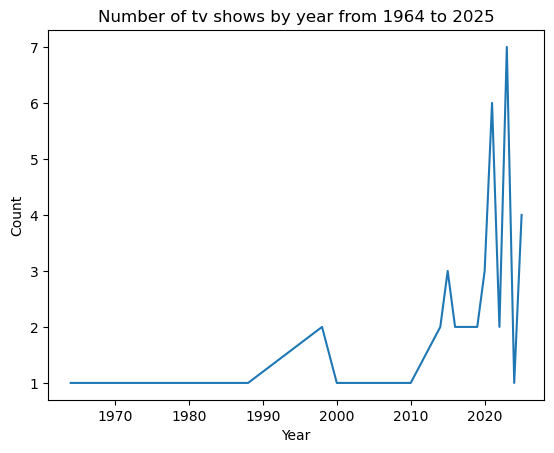

In [109]:
df_tv_by_year = df_tv.groupby(['year'])['title'].count().reset_index()
plt.plot(df_tv_by_year['year'], df_tv_by_year['title'])
plt.title('Number of tv shows by year from 1964 to 2025')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

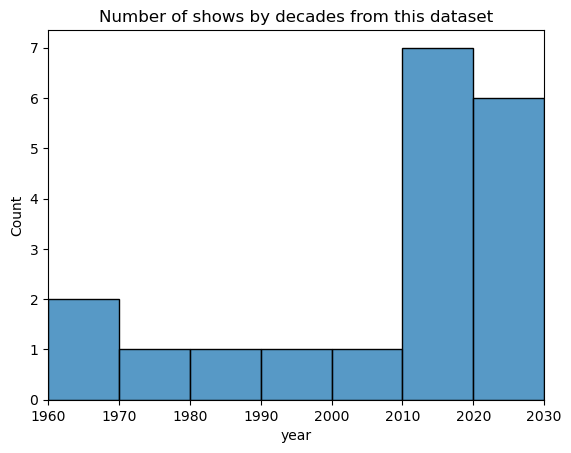

In [110]:
sns.histplot(df_tv_by_year['year'], binwidth = 10, binrange = [1960, 2030])
plt.xlim(1960, 2030)
plt.title('Number of shows by decades from this dataset')
plt.show()

## Overview of tv shows critics score

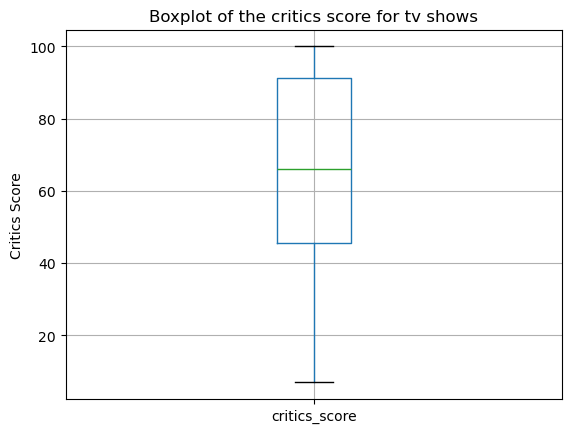

In [111]:
df_tv.boxplot(['critics_score'])
plt.title('Boxplot of the critics score for tv shows')
plt.ylabel('Critics Score')
plt.show()

In [112]:
print('Average critics score for tv shows:', round(np.mean(df_tv['critics_score']), 2))
print('Max critics score for tv shows:', max(df_tv['critics_score']))
print('Min critics score for tv shows:', min(df_tv['critics_score']))
print('Median critics score for tv shows:', (df_tv['critics_score'].median()))
print('Standard deviation of critics score for tv shows:', round(np.std(df_tv['critics_score']), 2))

Average critics score for tv shows: 65.43
Max critics score for tv shows: 100.0
Min critics score for tv shows: 7.0
Median critics score for tv shows: 66.0
Standard deviation of critics score for tv shows: 26.53


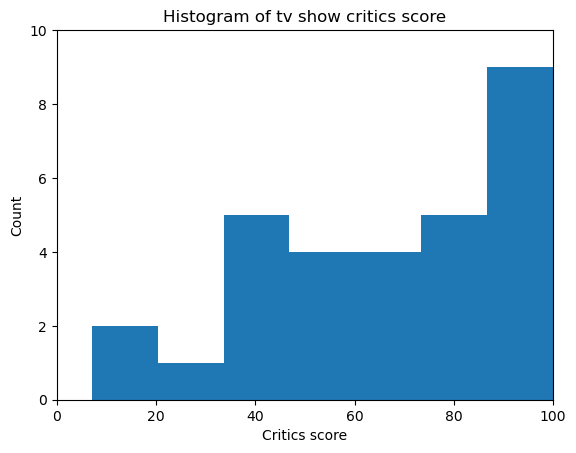

In [113]:
plt.hist(df_tv['critics_score'], bins = 7)
plt.title('Histogram of tv show critics score')
plt.xlabel('Critics score')
plt.xlim([0,100])
plt.ylabel('Count')
plt.ylim([0,10])
plt.show()

In [114]:
df_tv[df_tv['critics_score'] == 100]

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews
1342,Love & Death,2023,b755c2cd-f390-36ab-8c2a-b85b73db4355,love_and_death,tv,100.0,90.0,[Mystery & Thriller],[],"[{'role': 'Actor', 'emsId': 'fc6c2d2d-cb20-37b...",Critics Consensus\n \nWoody Allen plunk...,Love and Death,https://resizing.flixster.com/y0VqjljL6_H66j7w...,"[{'critic_name': 'Grant Watson', 'review_text'..."
2487,Kolchak: The Night Stalker,1974,d6860798-f6bc-3859-a198-62494b5a0952,kolchak_the_night_stalker,tv,100.0,94.0,"[Drama, Mystery & Thriller]",[],"[{'role': 'Actor', 'emsId': '5e912c9e-4891-38b...",None,Kolchak: The Night Stalker,none,"[{'critic_name': 'Matt Brunson', 'review_text'..."


In [115]:
df_tv[df_tv['critics_score'] == 7]

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews
2714,All the Queen's Men,2021,dc4d5dac-1cd6-316f-979d-bdd6a87243fc,all_the_queens_men,tv,7.0,51.0,[Drama],[],"[{'role': 'Actor', 'emsId': 'fafc2f8e-7aae-309...",Critics Consensus\n \nAll the Queen's M...,All the Queen's Men,https://resizing.flixster.com/ckExmT0cveczDBhh...,"[{'critic_name': 'Dennis Harvey', 'review_text..."


In [116]:
print('Lowest critics score tv show is', df_tv[df_tv['critics_score'] == 7].iloc[0]['title'])

Lowest critics score tv show is All the Queen's Men


## Overview of audience scores for tv shows

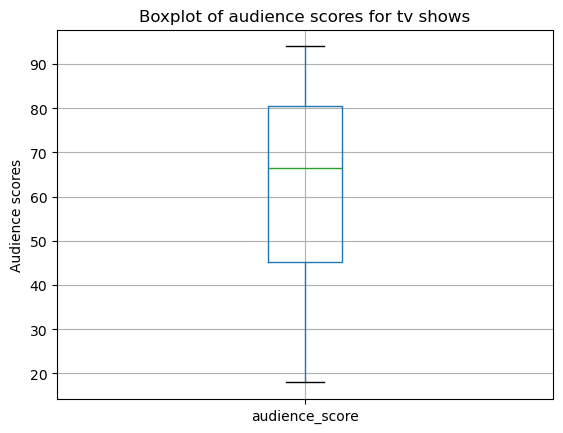

In [117]:
df_tv.boxplot(['audience_score'])
plt.title('Boxplot of audience scores for tv shows')
plt.ylabel('Audience scores')
plt.show()

In [118]:
print('Average audience score for tv shows:', round(np.mean(df_tv['audience_score']), 2))
print('Max audience score for tv shows:', max(df_tv['audience_score']))
print('Min audience score for tv shows:', min(df_tv['audience_score']))
print('Median audience score for tv shows:', np.median(df_tv['audience_score']))
print('Standard deviation of audience score for tv shows:', round(np.std(df_tv['audience_score']), 2))

Average audience score for tv shows: 62.61
Max audience score for tv shows: 94.0
Min audience score for tv shows: 18.0
Median audience score for tv shows: 66.5
Standard deviation of audience score for tv shows: 22.4


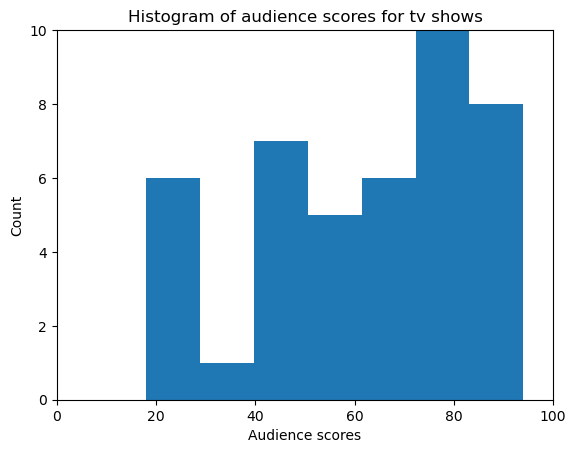

In [119]:
plt.hist(df_tv['audience_score'], bins = 7)
plt.title('Histogram of audience scores for tv shows')
plt.xlim([0, 100])
plt.ylim([0,10])
plt.xlabel('Audience scores')
plt.ylabel('Count')
plt.show()

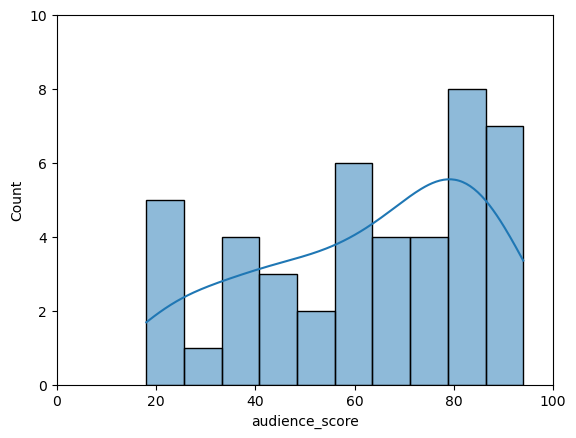

In [120]:
sns.histplot(df_tv['audience_score'], binwidth = 8, kde = True)
plt.xlim([0,100])
plt.ylim([0,10])
plt.show()

In [121]:
df_tv[df_tv['audience_score'] == 94]

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews
2487,Kolchak: The Night Stalker,1974,d6860798-f6bc-3859-a198-62494b5a0952,kolchak_the_night_stalker,tv,100.0,94.0,"[Drama, Mystery & Thriller]",[],"[{'role': 'Actor', 'emsId': '5e912c9e-4891-38b...",None,Kolchak: The Night Stalker,none,"[{'critic_name': 'Matt Brunson', 'review_text'..."


In [122]:
print('Highest audience score tv show is:', df_tv[df_tv['audience_score'] == 94].iloc[0]['title'])

Highest audience score tv show is: Kolchak: The Night Stalker


In [123]:
df_tv[df_tv['audience_score'] == 18]

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews
1593,Red Alert,2025,07cf2389-7310-3ece-a1ee-a98944c75b79,red_alert,tv,NaN,18.0,[Drama],[],"[{'role': 'Actor', 'emsId': 'b7196339-594c-329...",None,Red Alert,none,[]


In [124]:
print('Lowest audience score tv show is:', df_tv[df_tv['audience_score'] == 18].iloc[0]['title'])

Lowest audience score tv show is: Red Alert


## Q1: Which year produced tv shows with highest average scores?

In [125]:
df_tv_score_by_year = df_tv.groupby('year')['critics_score'].agg(
    n_tv_critics_score = 'count',
    mean_tv_critics_score = 'mean',
    std_tv_critics_score = 'std'
).sort_values('mean_tv_critics_score', ascending = False).reset_index()
df_tv_score_by_year.head()

,year,n_tv_critics_score,mean_tv_critics_score,std_tv_critics_score
0,1974,1,100.0,NaN
1,1988,1,96.0,NaN
2,2014,2,95.0,2.828427
3,2019,2,92.5,4.949747
4,2022,2,87.5,6.363961


Why there is NaN ? 

Answer: If there is only 1 entry for year 1964 and it's Nan, then the result will be Nan. Below is the verification.

In [126]:
df_tv[df_tv['year'] == 1964]

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews
2885,Jonny Quest,1964,692a1e84-dc8c-32fd-bb5d-b88178cbf087,jonny_quest,tv,NaN,80.0,"[Kids & Family, Adventure, Mystery & Thriller,...",[],"[{'role': 'Voice', 'emsId': 'db58adde-e44f-3f2...",None,Flintstones and Jonny Quest,none,[]


In [127]:
df_tv_score_by_year.sort_values('mean_tv_critics_score', ascending = False).head()

,year,n_tv_critics_score,mean_tv_critics_score,std_tv_critics_score
0,1974,1,100.0,NaN
1,1988,1,96.0,NaN
2,2014,2,95.0,2.828427
3,2019,2,92.5,4.949747
4,2022,2,87.5,6.363961


Highest average critics score for tv shows is in year 1974.

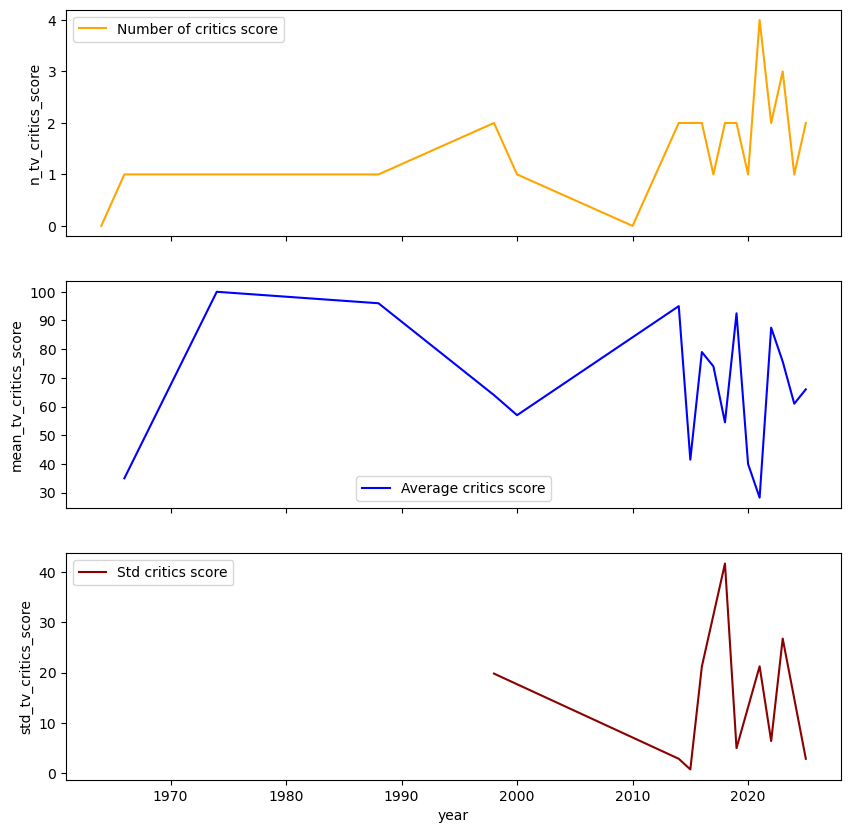

In [128]:
fig, axes = plt.subplots(3, sharex = True, figsize = (10,10))
sns.lineplot(
    data = df_tv_score_by_year, 
    x = 'year', 
    y = 'n_tv_critics_score', 
    label = 'Number of critics score', 
    ax = axes[0], 
    color = 'orange')
sns.lineplot(
    data = df_tv_score_by_year, 
    x = 'year', 
    y = 'mean_tv_critics_score', 
    label = 'Average critics score', 
    ax = axes[1], 
    color = 'blue')
sns.lineplot(
    data = df_tv_score_by_year,
    x = 'year',
    y = 'std_tv_critics_score',
    label = 'Std critics score',
    ax = axes[2],
    color = 'darkred'
)

plt.show()

The trend is not very clear. Maybe grouping the entries into decade (instead of year) can help.

In [129]:
df_tv.groupby('year')['audience_score'].agg(
    n_audience_scores = 'count',
    mean_audience_scores = 'mean',
    std_audience_scores = 'std'
).sort_values('mean_audience_scores', ascending = False).reset_index().head()

,year,n_audience_scores,mean_audience_scores,std_audience_scores
0,1974,1,94.0,NaN
1,1988,1,92.0,NaN
2,2022,2,82.5,3.535534
3,2000,1,82.0,NaN
4,2016,2,81.5,2.121320


Highest average audience score for tv shows is in year 1974.

## Grouping tv shows by decade and looking for the score trend

In [130]:
bins = [1960, 1970, 1980, 1990, 2000, 2010, 2020, 2030]
labels = ['60s', '70s', '80s', '90s', '00s', '10s', '20s']
df_tv['decade'] = pd.cut(
    df_tv['year'],
    bins = bins,
    labels = labels,
    right = False
)
df_tv.head()

/var/folders/z4/7bgbw8p550b8mfxtzx6_bgy80000gp/T/ipykernel_1226/1171789983.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tv['decade'] = pd.cut(


,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews,decade
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,"[Drama, Sci-Fi]",[],"[{'role': 'Actor', 'emsId': 'a68b7fcd-3c7f-32a...",Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"[{'critic_name': 'Milton Shulman', 'review_tex...",10s
79,War Sailor,2023,f3ce0a76-0219-3e2e-af14-b5533cee8bce,war_sailor,tv,80.0,92.0,"[History, Drama, War]",[],"[{'role': 'Actor', 'emsId': '1779020a-9b06-3d5...",None,War Sailor,https://resizing.flixster.com/n58jehm8qndsGywB...,"[{'critic_name': 'Stephanie Bunbury', 'review_...",20s
305,Zero Day,2025,f44a5d96-229e-32f4-b74a-45135a848502,zero_day,tv,68.0,75.0,"[Drama, Mystery & Thriller]",[],"[{'role': 'Actor', 'emsId': '5e39a39b-e16c-3d3...",None,Zero Day,none,"[{'critic_name': 'Jean-François Vandeuren', 'r...",20s
442,Day of the Dead,2021,b6e4e194-e5b9-3118-9483-5898ca2c86e0,day_of_the_dead,tv,13.0,22.0,"[Horror, Comedy, Action]",[],"[{'role': 'Actor', 'emsId': 'bc6db021-58d4-38a...",None,Day of the Dead,https://resizing.flixster.com/shdkKSBH6clljwv1...,"[{'critic_name': 'Jordan Snowden', 'review_tex...",20s
453,Training Day,2017,8729e3c3-2655-3b28-93af-a12bdaae3afd,training_day,tv,74.0,89.0,"[Crime, Drama]",[],"[{'role': 'Actor', 'emsId': 'db436e35-d508-383...",Critics Consensus\n \nThe ending may be...,Training Day,https://resizing.flixster.com/0HOWfjbdNIXzPu_g...,"[{'critic_name': 'Mike Massie', 'review_text':...",10s


In [131]:
1987//10

198

In [132]:
df_tv['decade_by_mapping'] = (df_tv['year']//10*10).map(
    {
        1960: '60s',
        1970: '70s',
        1980: '80s',
        1990: '90s',
        2000: '00s',
        2010: '10s',
        2020: '20s'
    }
)

/var/folders/z4/7bgbw8p550b8mfxtzx6_bgy80000gp/T/ipykernel_1226/2779346193.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tv['decade_by_mapping'] = (df_tv['year']//10*10).map(


In [133]:
df_tv_by_decades_n = df_tv.groupby(['decade'], observed = True)['title'].agg(n_titles = 'count').reset_index()

In [134]:
df_tv_by_decades_critics = df_tv.groupby(['decade'], observed = True)['critics_score'].agg(
    mean_critics = 'mean',
    std_critics = 'std',
    n_critics = 'count'
).reset_index()
df_tv_by_decades_critics

,decade,mean_critics,std_critics,n_critics
0,60s,35.000000,NaN,1
1,70s,100.000000,NaN,1
2,80s,96.000000,NaN,1
3,90s,64.000000,19.798990,2
4,00s,57.000000,NaN,1
5,10s,72.636364,25.869954,11
6,20s,57.538462,28.153198,13


In [135]:
df_tv_by_decades_audience = df_tv.groupby(['decade'], observed = True)['audience_score'].agg(
    mean_audience = 'mean',
    std_audience = 'std',
    n_audience = 'count'
).reset_index()
df_tv_by_decades_audience

,decade,mean_audience,std_audience,n_audience
0,60s,63.000000,24.041631,2
1,70s,94.000000,NaN,1
2,80s,92.000000,NaN,1
3,90s,76.500000,0.707107,2
4,00s,82.000000,NaN,1
5,10s,61.642857,21.574940,14
6,20s,58.478261,23.775215,23


In [136]:
df_tv_decade_score = pd.merge(df_tv_by_decades_critics, df_tv_by_decades_audience)
df_tv_decades = pd.merge(df_tv_decade_score, df_tv_by_decades_n)
df_tv_decades

,decade,mean_critics,std_critics,n_critics,mean_audience,std_audience,n_audience,n_titles
0,60s,35.000000,NaN,1,63.000000,24.041631,2,2
1,70s,100.000000,NaN,1,94.000000,NaN,1,1
2,80s,96.000000,NaN,1,92.000000,NaN,1,1
3,90s,64.000000,19.798990,2,76.500000,0.707107,2,2
4,00s,57.000000,NaN,1,82.000000,NaN,1,1
5,10s,72.636364,25.869954,11,61.642857,21.574940,14,14
6,20s,57.538462,28.153198,13,58.478261,23.775215,23,23


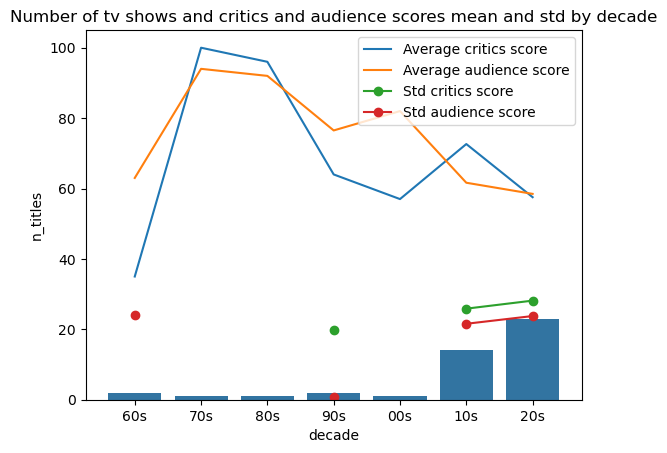

In [137]:
sns.barplot(data = df_tv_decades, x = 'decade', y = 'n_titles')
sns.lineplot(data = df_tv_decades, x = 'decade', y = 'mean_critics', label = 'Average critics score')
sns.lineplot(data = df_tv_decades, x = 'decade', y = 'mean_audience', label = 'Average audience score')
plt.plot(df_tv_decades['decade'], df_tv_decades['std_critics'], label = 'Std critics score', marker = 'o')
plt.plot(df_tv_decades['decade'], df_tv_decades['std_audience'], label = 'Std audience score', marker = 'o')
plt.title('Number of tv shows and critics and audience scores mean and std by decade')
plt.legend()
plt.show()

The highest average scores for both critics and audience occurred in the 70s.

The average score in recent years are lower than early years. 

This is most likely due to the increased amount of tv shows.

## Q2: Which genres are mostly produced for tv shows?

In [138]:
df_tv_genre_exploded = df_tv.explode('genres')
df_tv_genre_exploded.head(5)

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews,decade,decade_by_mapping
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,Drama,[],"[{'role': 'Actor', 'emsId': 'a68b7fcd-3c7f-32a...",Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"[{'critic_name': 'Milton Shulman', 'review_tex...",10s,10s
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,Sci-Fi,[],"[{'role': 'Actor', 'emsId': 'a68b7fcd-3c7f-32a...",Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"[{'critic_name': 'Milton Shulman', 'review_tex...",10s,10s
79,War Sailor,2023,f3ce0a76-0219-3e2e-af14-b5533cee8bce,war_sailor,tv,80.0,92.0,History,[],"[{'role': 'Actor', 'emsId': '1779020a-9b06-3d5...",None,War Sailor,https://resizing.flixster.com/n58jehm8qndsGywB...,"[{'critic_name': 'Stephanie Bunbury', 'review_...",20s,20s
79,War Sailor,2023,f3ce0a76-0219-3e2e-af14-b5533cee8bce,war_sailor,tv,80.0,92.0,Drama,[],"[{'role': 'Actor', 'emsId': '1779020a-9b06-3d5...",None,War Sailor,https://resizing.flixster.com/n58jehm8qndsGywB...,"[{'critic_name': 'Stephanie Bunbury', 'review_...",20s,20s
79,War Sailor,2023,f3ce0a76-0219-3e2e-af14-b5533cee8bce,war_sailor,tv,80.0,92.0,War,[],"[{'role': 'Actor', 'emsId': '1779020a-9b06-3d5...",None,War Sailor,https://resizing.flixster.com/n58jehm8qndsGywB...,"[{'critic_name': 'Stephanie Bunbury', 'review_...",20s,20s


In [139]:
df_tv_genre_count = df_tv_genre_exploded.value_counts(['genres']).reset_index()
df_tv_genre_count

,genres,count
0,Drama,32
1,Mystery & Thriller,13
2,Crime,8
3,Action,7
4,Sci-Fi,6
5,Horror,5
6,Adventure,4
7,Kids & Family,3
8,Documentary,3
9,Animation,3


In [140]:
len(df_tv_genre_exploded['genres'].unique())

22

There are 22 genres for tv shows in this dataset.

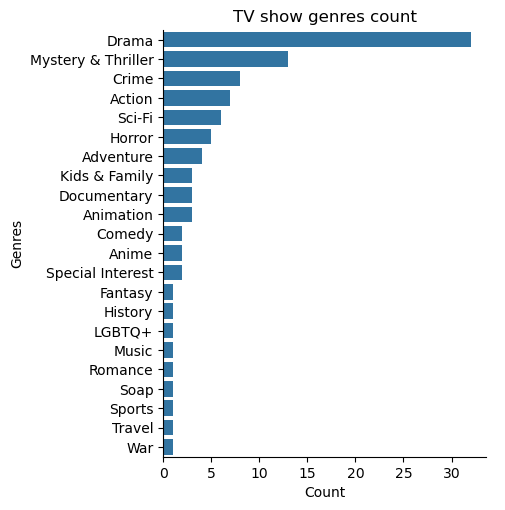

In [141]:
g_tv = sns.catplot(data = df_tv_genre_count, y = 'genres', x = 'count', kind = 'bar')
# g_tv.set_xticklabels(rotation = 45, ha = 'right')
g_tv.set_xlabels('Count')
g_tv.set_ylabels('Genres')
plt.title('TV show genres count')
plt.show()

**Top 3 genres of tv shows in this dataset is Drama, Mystery & Thriller, followed by Crime.**

In [142]:
df_tv_drama = df_tv_genre_exploded[df_tv_genre_exploded['genres'] == 'Drama']
df_tv_drama[df_tv_drama['audience_score'] == max(df_tv_drama['audience_score'])]

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews,decade,decade_by_mapping
2487,Kolchak: The Night Stalker,1974,d6860798-f6bc-3859-a198-62494b5a0952,kolchak_the_night_stalker,tv,100.0,94.0,Drama,[],"[{'role': 'Actor', 'emsId': '5e912c9e-4891-38b...",None,Kolchak: The Night Stalker,none,"[{'critic_name': 'Matt Brunson', 'review_text'...",70s,70s


In [143]:
df_tv_drama[df_tv_drama['critics_score'] == max(df_tv_drama['critics_score'])]

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews,decade,decade_by_mapping
2487,Kolchak: The Night Stalker,1974,d6860798-f6bc-3859-a198-62494b5a0952,kolchak_the_night_stalker,tv,100.0,94.0,Drama,[],"[{'role': 'Actor', 'emsId': '5e912c9e-4891-38b...",None,Kolchak: The Night Stalker,none,"[{'critic_name': 'Matt Brunson', 'review_text'...",70s,70s


The most highly rated Drama tv show by both audience and critics is Kolchak: The Night Stalker.

In [144]:
df_tv_drama[df_tv_drama['audience_score'] == min(df_tv_drama['audience_score'])]

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews,decade,decade_by_mapping
1593,Red Alert,2025,07cf2389-7310-3ece-a1ee-a98944c75b79,red_alert,tv,NaN,18.0,Drama,[],"[{'role': 'Actor', 'emsId': 'b7196339-594c-329...",None,Red Alert,none,[],20s,20s


In [145]:
df_tv_drama[df_tv_drama['critics_score'] == min(df_tv_drama['critics_score'])]

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews,decade,decade_by_mapping
2714,All the Queen's Men,2021,dc4d5dac-1cd6-316f-979d-bdd6a87243fc,all_the_queens_men,tv,7.0,51.0,Drama,[],"[{'role': 'Actor', 'emsId': 'fafc2f8e-7aae-309...",Critics Consensus\n \nAll the Queen's M...,All the Queen's Men,https://resizing.flixster.com/ckExmT0cveczDBhh...,"[{'critic_name': 'Dennis Harvey', 'review_text...",20s,20s


The lowest rated tv show by audience is Red Alert. 
The lowest rated tv show by critics is All the Queen's Men.

#### The highest audience rated tv shows in the dataset by genre

In [146]:
tv_genres = df_tv_genre_exploded['genres'].unique()
tv_genres_ls = list(tv_genres)

In [147]:
for genre in tv_genres_ls:
    df_tv_genre_exploded_one = df_tv_genre_exploded[df_tv_genre_exploded['genres'] == genre]
    highest_audience_score = df_tv_genre_exploded_one[df_tv_genre_exploded_one['audience_score'] == max(df_tv_genre_exploded_one['audience_score'])]
    print(highest_audience_score[['genres', 'title', 'year']])
    print('-'*30)

     genres                       title  year
2487  Drama  Kolchak: The Night Stalker  1974
------------------------------
    genres                  title  year
43  Sci-Fi  The War of the Worlds  2019
------------------------------
     genres       title  year
79  History  War Sailor  2023
------------------------------
   genres       title  year
79    War  War Sailor  2023
------------------------------
                  genres                       title  year
2487  Mystery & Thriller  Kolchak: The Night Stalker  1974
------------------------------
      genres            title  year
1813  Horror  Rosemary's Baby  2014
------------------------------
      genres             title  year
1784  Comedy  Sex and the City  1998
------------------------------
      genres       title  year
1578  Action  The Rookie  2018
------------------------------
     genres                     title  year
2539  Crime  In the Heat of the Night  1988
------------------------------
         genres    

## Q3: Which genres are associated with high ratings?

## Best genres by critic scores

In [148]:
df_tv_genre_exploded.head()

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews,decade,decade_by_mapping
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,Drama,[],"[{'role': 'Actor', 'emsId': 'a68b7fcd-3c7f-32a...",Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"[{'critic_name': 'Milton Shulman', 'review_tex...",10s,10s
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,Sci-Fi,[],"[{'role': 'Actor', 'emsId': 'a68b7fcd-3c7f-32a...",Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"[{'critic_name': 'Milton Shulman', 'review_tex...",10s,10s
79,War Sailor,2023,f3ce0a76-0219-3e2e-af14-b5533cee8bce,war_sailor,tv,80.0,92.0,History,[],"[{'role': 'Actor', 'emsId': '1779020a-9b06-3d5...",None,War Sailor,https://resizing.flixster.com/n58jehm8qndsGywB...,"[{'critic_name': 'Stephanie Bunbury', 'review_...",20s,20s
79,War Sailor,2023,f3ce0a76-0219-3e2e-af14-b5533cee8bce,war_sailor,tv,80.0,92.0,Drama,[],"[{'role': 'Actor', 'emsId': '1779020a-9b06-3d5...",None,War Sailor,https://resizing.flixster.com/n58jehm8qndsGywB...,"[{'critic_name': 'Stephanie Bunbury', 'review_...",20s,20s
79,War Sailor,2023,f3ce0a76-0219-3e2e-af14-b5533cee8bce,war_sailor,tv,80.0,92.0,War,[],"[{'role': 'Actor', 'emsId': '1779020a-9b06-3d5...",None,War Sailor,https://resizing.flixster.com/n58jehm8qndsGywB...,"[{'critic_name': 'Stephanie Bunbury', 'review_...",20s,20s


In [149]:
df_tv_genre_exploded.groupby(['genres'])['critics_score'].agg(
    n_critics_score_by_genre = 'count',
    mean_critics_score_by_genre = 'mean',
    std_critics_score_by_genre = 'std'
).sort_values('mean_critics_score_by_genre', ascending = False).head(10)

,n_critics_score_by_genre,mean_critics_score_by_genre,std_critics_score_by_genre
genres,,,
LGBTQ+,1,92.000000,NaN
Crime,5,82.400000,13.520355
War,1,80.000000,NaN
History,1,80.000000,NaN
Drama,22,68.727273,24.413466
Mystery & Thriller,9,65.666667,27.023138
Kids & Family,2,65.500000,24.748737
Animation,2,65.500000,24.748737
Special Interest,2,65.500000,24.748737


Top 3 highly rated genres based on critics scores are LGBTQ+, Crime and War. Note that for LGBTQ+ and War, there is only one critic score for each.

## Best genres by audience scores

In [150]:
df_tv_genre_exploded.groupby(['genres'])['audience_score'].agg(
    n_audience_score_by_genre = 'count',
    mean_audience_score_by_genre = 'mean',
    std_audience_score_by_genre = 'std'
).sort_values('mean_audience_score_by_genre', ascending = False).head(10)

,n_audience_score_by_genre,mean_audience_score_by_genre,std_audience_score_by_genre
genres,,,
War,1,92.000000,NaN
History,1,92.000000,NaN
LGBTQ+,1,85.000000,NaN
Sports,1,80.000000,NaN
Crime,8,70.750000,19.969620
Kids & Family,3,68.666667,19.629909
Animation,3,68.666667,19.629909
Mystery & Thriller,13,64.538462,24.938643
Drama,32,63.625000,22.212682


Top 3 highly rated genres based on audience scores are War, History and LGBTQ+. Note that for all three genres, there is only one audience score for each.

## Q4: Are critics score and audience score always aligned?

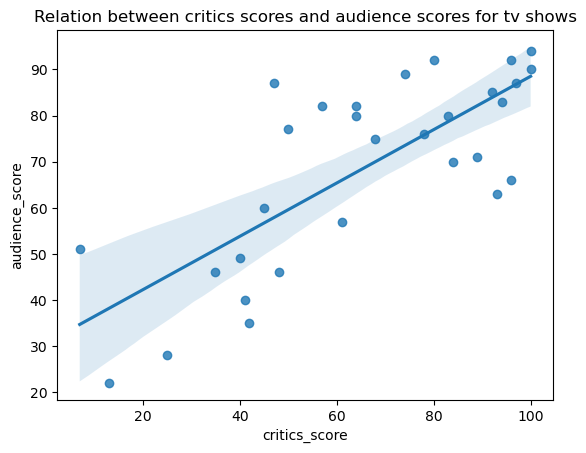

In [151]:
sns.regplot(data = df_tv, x ='critics_score', y ='audience_score')
# no use of lowess = True, because data points < 50.
plt.title('Relation between critics scores and audience scores for tv shows')
plt.show()

In [152]:
round(df_tv['critics_score'].corr(df_tv['audience_score']), 2)

0.76

#### Critics’ and audience scores show a strong positive correlation (Pearson r = 0.76).

In [153]:
round(df_tv['critics_score'].corr(df_tv['audience_score'], method = 'spearman'), 2)

0.72

#### Critics and audience rankings also show strong agreement (Spearman ρ = 0.72).

In [154]:
mad = (df_tv['critics_score'] - df_tv['audience_score']).abs().mean()
round(mad, 2)

13.67

#### On average, critics and audience scores differ by 13.67 points.

In [155]:
rmse = ((df_tv['critics_score'] - df_tv['audience_score'])**2).mean()**0.5
round(rmse, 2)

17.54

## Actor names count

In [156]:
df_tv['cast'].iloc[0]

[{'role': 'Actor',
  'emsId': 'a68b7fcd-3c7f-32ac-85ab-7a07e42768f0',
  'name': 'Rafe Spall',
  'personId': '283126'},
 {'role': 'Actor',
  'emsId': '90fa4580-1d10-3d7e-86cc-1c24c00b0649',
  'name': 'Eleanor Tomlinson',
  'personId': '489686'},
 {'role': 'Actor',
  'emsId': 'ab2226bd-1280-37f2-a00e-db96fdffd35a',
  'name': 'Rupert Graves',
  'personId': '74069'},
 {'role': 'Actor',
  'emsId': '348d2dc2-6afa-379b-aaea-402d17f87fa2',
  'name': 'Robert Carlyle',
  'personId': '54979'},
 {'role': 'Actor',
  'emsId': 'aa690375-e70d-3566-9883-b73262448a3e',
  'name': 'Taliyah Blair',
  'personId': '1253136'},
 {'role': 'Actor',
  'emsId': '08c51a74-6d47-3866-b5a3-21251ab8659f',
  'name': 'Jonathan Aris',
  'personId': '164623'},
 {'role': 'Actor',
  'emsId': '4dc938eb-9737-35bd-a6cc-76f1bd824923',
  'name': 'Philip Gascoyne',
  'personId': '1193870'}]

In [157]:
df_tv_cast_exploded = df_tv.explode(['cast'])
df_tv_cast_exploded.head()

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews,decade,decade_by_mapping
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,"[Drama, Sci-Fi]",[],"{'role': 'Actor', 'emsId': 'a68b7fcd-3c7f-32ac...",Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"[{'critic_name': 'Milton Shulman', 'review_tex...",10s,10s
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,"[Drama, Sci-Fi]",[],"{'role': 'Actor', 'emsId': '90fa4580-1d10-3d7e...",Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"[{'critic_name': 'Milton Shulman', 'review_tex...",10s,10s
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,"[Drama, Sci-Fi]",[],"{'role': 'Actor', 'emsId': 'ab2226bd-1280-37f2...",Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"[{'critic_name': 'Milton Shulman', 'review_tex...",10s,10s
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,"[Drama, Sci-Fi]",[],"{'role': 'Actor', 'emsId': '348d2dc2-6afa-379b...",Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"[{'critic_name': 'Milton Shulman', 'review_tex...",10s,10s
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,"[Drama, Sci-Fi]",[],"{'role': 'Actor', 'emsId': 'aa690375-e70d-3566...",Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"[{'critic_name': 'Milton Shulman', 'review_tex...",10s,10s


In [158]:
df_tv_cast_exploded.shape

(401, 16)

In [159]:
df_tv_cast_exploded['cast'].iloc[0]

{'role': 'Actor',
 'emsId': 'a68b7fcd-3c7f-32ac-85ab-7a07e42768f0',
 'name': 'Rafe Spall',
 'personId': '283126'}

In [160]:
df_tv_cast_exploded[df_tv_cast_exploded['cast'].isnull()]

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews,decade,decade_by_mapping
2393,The Night Caller,2020,1c012df4-0894-35e5-be48-e5a9e58b370d,the_night_caller,tv,NaN,43.0,"[Documentary, Crime]",[],NaN,None,The Night Caller,https://resizing.flixster.com/lo-ySnOVDExk3hHG...,"[{'critic_name': 'Dennis Schwartz', 'review_te...",20s,20s


In [161]:
df_tv_cast_exploded.dropna(subset = 'cast', inplace = True)

In [162]:
df_tv_cast_exploded['cast'].apply(lambda x: x.get('role')).unique()

array(['Actor', 'Voice', 'Self', 'Host'], dtype=object)

In [163]:
df_tv_cast_exploded.shape

(400, 16)

In [164]:
actors = (df_tv_cast_exploded['cast']
        .apply(lambda x: x.get('name') if x.get('role') == 'Actor' else None)
        .replace('', np.nan).dropna().unique()
        .tolist()
         )
len(actors)

360

There are 360 actors in all the tv shows in this dataset.

In [165]:
actors_count = (df_tv_cast_exploded['cast']
        .apply(lambda x: x.get('name') if x.get('role') == 'Actor' else None)
        .replace('', np.nan).dropna()
        .value_counts()
         )
actors_count.head(10)

cast
Ryan Hurst           2
Gabriel Luna         2
Wilson Bethel        2
Vincent D'Onofrio    2
Jon Bernthal         2
Melissa O'Neil       2
Daniella Alonso      2
Melanie Liburd       2
Jesse Plemons        2
Ruth McDevitt        1
Name: count, dtype: int64

## Q5: Which actor is associated with high ratings?

In [166]:
df_tv_cast_exploded_flatten = pd.concat(
    [df_tv_cast_exploded.drop(columns = 'cast'), df_tv_cast_exploded['cast'].apply(pd.Series)],
    axis = 1
)
df_tv_cast_exploded_flatten.head()

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,full_consensus,full_title,full_image,critic_reviews,decade,decade_by_mapping,role,emsId,name,personId
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,"[Drama, Sci-Fi]",[],Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"[{'critic_name': 'Milton Shulman', 'review_tex...",10s,10s,Actor,a68b7fcd-3c7f-32ac-85ab-7a07e42768f0,Rafe Spall,283126
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,"[Drama, Sci-Fi]",[],Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"[{'critic_name': 'Milton Shulman', 'review_tex...",10s,10s,Actor,90fa4580-1d10-3d7e-86cc-1c24c00b0649,Eleanor Tomlinson,489686
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,"[Drama, Sci-Fi]",[],Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"[{'critic_name': 'Milton Shulman', 'review_tex...",10s,10s,Actor,ab2226bd-1280-37f2-a00e-db96fdffd35a,Rupert Graves,74069
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,"[Drama, Sci-Fi]",[],Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"[{'critic_name': 'Milton Shulman', 'review_tex...",10s,10s,Actor,348d2dc2-6afa-379b-aaea-402d17f87fa2,Robert Carlyle,54979
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,"[Drama, Sci-Fi]",[],Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"[{'critic_name': 'Milton Shulman', 'review_tex...",10s,10s,Actor,aa690375-e70d-3566-9883-b73262448a3e,Taliyah Blair,1253136


In [167]:
df_tv_cast_exploded_flatten.groupby(['name', 'role'])['critics_score'].agg(
    n_critic_score_by_actor = 'count',
    mean_critic_score_by_actor = 'mean',
    std_critic_score_by_actor = 'std'
).sort_values('mean_critic_score_by_actor', ascending = False).head(10)

,,n_critic_score_by_actor,mean_critic_score_by_actor,std_critic_score_by_actor
name,role,,,
Keir Gilchrist,Actor,1,100.0,NaN
Jack Grinnage,Actor,1,100.0,NaN
Patrick Fugit,Actor,1,100.0,NaN
Ruth McDevitt,Actor,1,100.0,NaN
Darren McGavin,Actor,1,100.0,NaN
Tom Pelphrey,Actor,1,100.0,NaN
Krysten Ritter,Actor,1,100.0,NaN
Elizabeth Olsen,Actor,1,100.0,NaN
Elizabeth Marvel,Actor,1,100.0,NaN


In [168]:
df_tv_cast_exploded_flatten.groupby(['name', 'role'])['audience_score'].agg(
    n_audience_score_by_actor = 'count',
    mean_audience_score_by_actor = 'mean',
    std_audience_score_by_actor = 'std'
).sort_values('mean_audience_score_by_actor', ascending = False).head(10)

,,n_audience_score_by_actor,mean_audience_score_by_actor,std_audience_score_by_actor
name,role,,,
Darren McGavin,Actor,1,94.0,NaN
Ruth McDevitt,Actor,1,94.0,NaN
Simon Oakland,Actor,1,94.0,NaN
Jack Grinnage,Actor,1,94.0,NaN
Howard E. Rollins,Actor,1,92.0,NaN
Anne-Marie Johnson,Actor,1,92.0,NaN
Armand Hannestad,Actor,1,92.0,NaN
Lois Nettleton,Actor,1,92.0,NaN
Hugh O'Connor,Actor,1,92.0,NaN


## Critic reviews

In [169]:
df_tv['critic_reviews'].iloc[0]

[{'critic_name': 'Milton Shulman',
  'review_text': 'The War of the Worlds is an impressive and spectacular example of science-fiction hokum with just enough moments of adult horror to merit its "X" certificate. But I shudder to think of what will happen to us should the Martians ever learn to gargle.'},
 {'critic_name': 'John Bustin',
  'review_text': "Though the terrifying effect of the movie version has been somewhat lessened by the frequency of similar interplanetary yarns, it's still a wildly imaginative thing that'll give the science-fiction fans a good workout."},
 {'critic_name': 'Mildred Martin',
  'review_text': 'Gaudily dressed in Technicolor, directed with all stops out by Byron Haskin, The War of the Worlds has been equipped by Barre Lyndon with a script Wells would probably be only too anxious to disown were he still around.'},
 {'critic_name': 'KC Star Staff',
  'review_text': 'A spine-tingling motion picture with impact.'},
 {'critic_name': 'Marjory Adams',
  'review_te

In [170]:
df_tv['critic_reviews'].iloc[0][0]['review_text']

'The War of the Worlds is an impressive and spectacular example of science-fiction hokum with just enough moments of adult horror to merit its "X" certificate. But I shudder to think of what will happen to us should the Martians ever learn to gargle.'

In [171]:
df_tv_reviews_exploded = df_tv.explode(['critic_reviews'])
df_tv_reviews_exploded.head()

,title,year,emsId,vanity,type,critics_score,audience_score,genres,directors,cast,full_consensus,full_title,full_image,critic_reviews,decade,decade_by_mapping
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,"[Drama, Sci-Fi]",[],"[{'role': 'Actor', 'emsId': 'a68b7fcd-3c7f-32a...",Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"{'critic_name': 'Milton Shulman', 'review_text...",10s,10s
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,"[Drama, Sci-Fi]",[],"[{'role': 'Actor', 'emsId': 'a68b7fcd-3c7f-32a...",Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"{'critic_name': 'John Bustin', 'review_text': ...",10s,10s
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,"[Drama, Sci-Fi]",[],"[{'role': 'Actor', 'emsId': 'a68b7fcd-3c7f-32a...",Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"{'critic_name': 'Mildred Martin', 'review_text...",10s,10s
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,"[Drama, Sci-Fi]",[],"[{'role': 'Actor', 'emsId': 'a68b7fcd-3c7f-32a...",Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"{'critic_name': 'KC Star Staff', 'review_text'...",10s,10s
43,The War of the Worlds,2019,5113220a-821a-3151-9477-587ed44ad9e4,the_war_of_the_worlds,tv,89.0,71.0,"[Drama, Sci-Fi]",[],"[{'role': 'Actor', 'emsId': 'a68b7fcd-3c7f-32a...",Critics Consensus\n \nThough it's dated...,The War of the Worlds,https://resizing.flixster.com/rdwvV3p00GD1CkcK...,"{'critic_name': 'Marjory Adams', 'review_text'...",10s,10s


In [172]:
df_tv_reviews_exploded.shape

(175, 16)

### Reviewers

In [173]:
reviewers = (df_tv_reviews_exploded['critic_reviews']
        .apply(lambda x: x.get('critic_name') if isinstance (x,dict) else None)
        .replace('', np.nan).dropna()
        .tolist())

In [174]:
len(set(reviewers))

138

There are 138 reviewers included in this dataset for tv shows.

# Conclusions

**Q1: Which year produced movies/tv shows with highest average scores?**

Movies 1929, which has 2 critics scores, and 1925 which has only 1 audience score.

TV shows 1974 based on both critics and audience scores.

**Q2: Which genres are mostly produced for movies and tv shows?**

Movies top 3 genres produced: Drama, Mystery & Thrill, Comedy

TV shows top 3 genres produced: Drama, Mystery & Thrill, Crime

**Q3: Which genres are associated with high ratings?**

Movies top 3 highest rated genres according to critics are Nature, Stand-Up, Short; Faith & Spirituality, Sports, Other	according to audience scores.

TV shows top 3 highest rated genres according to critics are LGBTQ+, Crime, War; War, History, LGBTQ+ according to audience scores.

**Q4: Are critics scores and audience scores always aligned?**

Movies Critics and audience scores show weak positive correlation, with Pearson value = 0.64.

TV shows Critics and audience scores show stronger positive correlation, with Pearson value = 0.76.

**Q5: Which actor is associated with high ratings?**

Movies top 3 actors associated with high ratings are Jeremy Renner, Maggie Smith, Mads Mikkelsen according to critics scores on the movies they are in, and Jeremy Renner, Benedict Cumberbatch, Chris Evans according to audience scores. 

TV shows dataset doesn't contain enough reviews regarding individual actors and therefore is not reprensetative.

**Limitations of Dataset**

- The dataset contains only 44 records of TV shows, which is not very comprehensive.
- *Director* columne is completely empty.
- Gender of actors is not included in the dataset.
- There were multiple genres in each movie, hence we split the genres such that each genre is allocated to 1 row.